### Importing packages and taking a first look at the data we will be using (airline data from sktime package)

In [38]:
!pip install --quiet sktime
!pip install --quiet xgboost

In [39]:
import sktime
from sktime import datasets
import numpy as np

In [40]:
data = datasets.load_airline()

In [41]:
data

Period
1949-01    112.0
1949-02    118.0
1949-03    132.0
1949-04    129.0
1949-05    121.0
           ...  
1960-08    606.0
1960-09    508.0
1960-10    461.0
1960-11    390.0
1960-12    432.0
Freq: M, Name: Number of airline passengers, Length: 144, dtype: float64

In [42]:
from sktime.utils.plotting import plot_series
from sktime.forecasting.model_selection import temporal_train_test_split

In [43]:
test_size = int(len(data)*0.2)
y_train, y_test = temporal_train_test_split(data, test_size = test_size)

In [44]:
print(f'Length of training data: {len(y_train)} | len of test data: {len(y_test)}')

Length of training data: 116 | len of test data: 28


(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

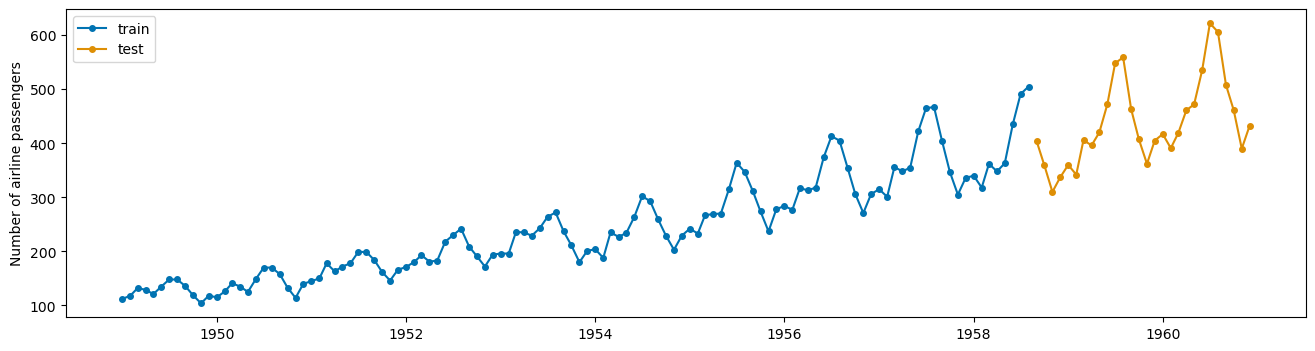

In [45]:
plot_series(y_train, y_test, labels = ['train', 'test']) #showing train and testing data

### Reduction of time series data to tabular data to enable use of regression algorithms (e.g., linear regression, etc.)

In [46]:
from sktime.forecasting.compose import make_reduction
from sklearn.linear_model import LinearRegression

In [47]:
linear_model = LinearRegression()
linear_fc = make_reduction(
    linear_model,
    window_length = 12,
    strategy = 'recursive'
)

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

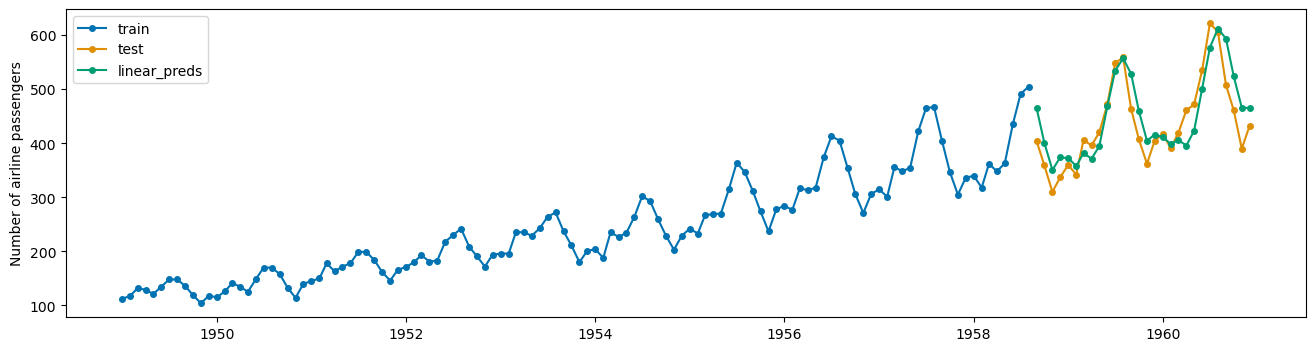

In [48]:
linear_fc.fit(y_train)
fh = np.arange(1, 29, 1)
linear_preds = linear_fc.predict(fh)
plot_series(y_train, y_test, linear_preds, labels = ['train', 'test', 'linear_preds'])

In [49]:
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
mape = MeanAbsolutePercentageError(symmetric=False)
smape = MeanAbsolutePercentageError(symmetric=True)
lm_mape_value = mape(y_test, linear_preds)
lm_smape_value = smape(y_test, linear_preds)
print(f'MAPE value: {lm_mape_value} | SMAPE value: {lm_smape_value}')

MAPE value: 0.08046498031488622 | SMAPE value: 0.07794729596327625


In [50]:
from sklearn.ensemble import RandomForestRegressor

In [51]:
rf_model = RandomForestRegressor()
rf_fc = make_reduction(
    rf_model,
    window_length = 12,
    strategy = 'recursive'
)

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

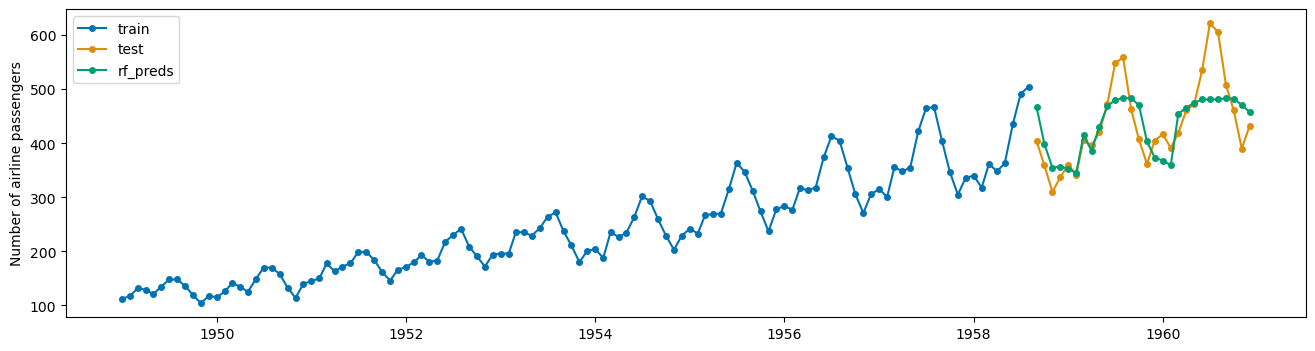

In [52]:
rf_fc.fit(y_train)
rf_preds = rf_fc.predict(fh)
plot_series(y_train, y_test, rf_preds, labels = ['train', 'test', 'rf_preds'])

In [53]:
mape = MeanAbsolutePercentageError(symmetric=False)
smape = MeanAbsolutePercentageError(symmetric=True)
rf_mape_value = mape(y_test, rf_preds)
rf_smape_value = smape(y_test, rf_preds)
print(f'MAPE value: {rf_mape_value} | SMAPE value: {rf_smape_value}')

MAPE value: 0.08638650943268099 | SMAPE value: 0.08703635183558138


In [54]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor()
xgb_fc = make_reduction(
    xgb_model,
    window_length = 12,
    strategy = 'recursive'
)

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

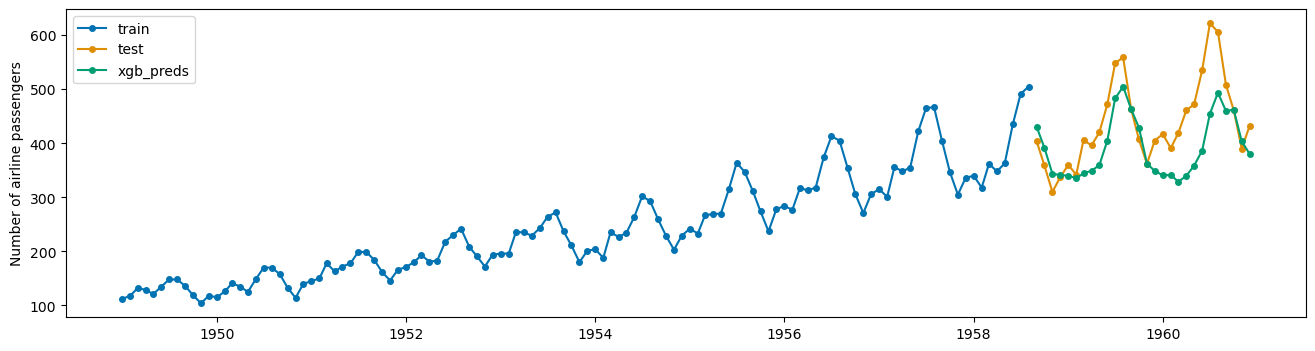

In [55]:
xgb_fc.fit(y_train)
xgb_preds = xgb_fc.predict(fh)
plot_series(y_train, y_test, xgb_preds, labels = ['train', 'test', 'xgb_preds'])

In [56]:
mape = MeanAbsolutePercentageError(symmetric=False)
smape = MeanAbsolutePercentageError(symmetric=True)
xgb_mape_value = mape(y_test, xgb_preds)
xgb_smape_value = smape(y_test, xgb_preds)
print(f'MAPE value: {xgb_mape_value} | SMAPE value: {xgb_smape_value}')

MAPE value: 0.1189362796918795 | SMAPE value: 0.12951942771978237


In [57]:
from sktime.forecasting.model_selection import ForecastingGridSearchCV, SlidingWindowSplitter
xgb_model = xgb.XGBRegressor(objective = 'reg:squarederror')
xgb_fc = make_reduction(
    xgb_model,
    window_length = 12,
    strategy = 'recursive'
)
cv = SlidingWindowSplitter(initial_window=20, window_length=12)
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1]
}
xgb_fc_gscv = ForecastingGridSearchCV(xgb_fc, strategy="refit", cv=cv, param_grid=param_grid)
xgb_fc_gscv.fit(y_train)
print(xgb_fc_gscv.best_params_)

{'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [58]:
best_xgb_model = xgb.XGBRegressor('reg:squarederror')
best_xgb_model.set_params(**xgb_fc_gscv.best_params_)
best_xgb_fc = make_reduction(
    best_xgb_model,
    window_length = 12,
    strategy = 'recursive'
)

C:\Users\akozi\anaconda3\Lib\site-packages\xgboost\core.py:748: FutureWarning: Pass `objective` as keyword args.
  warnings.warn(msg, FutureWarning)


(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

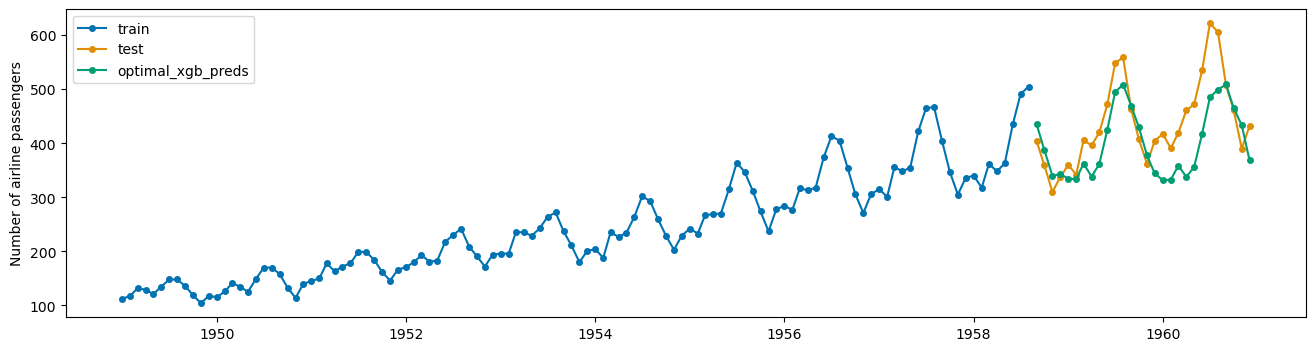

In [59]:
best_xgb_fc.fit(y_train)
best_xgb_preds = best_xgb_fc.predict(fh)
plot_series(y_train, y_test, best_xgb_preds, labels = ['train', 'test', 'optimal_xgb_preds'])

### Accounting for stationarity in data by using a differencer. The above data clearly both has a trend and seasonality, which could be leading to erroneous forecasting results depending on the model used.

In [60]:
from sktime.transformations.series.difference import Differencer
transformer_1 = Differencer(lags=1)
data_transformed_1 = transformer_1.fit_transform(data)

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

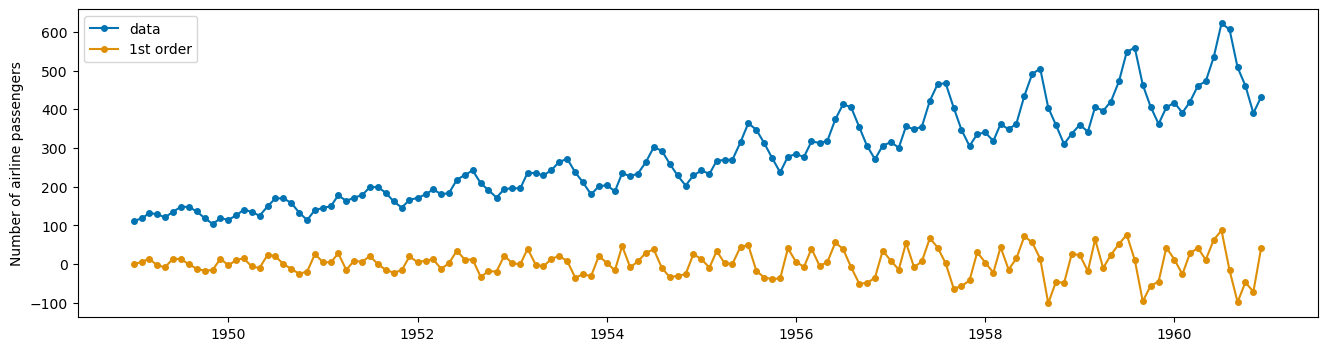

In [61]:
plot_series(data, data_transformed_1, labels = ['data', '1st order'])

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

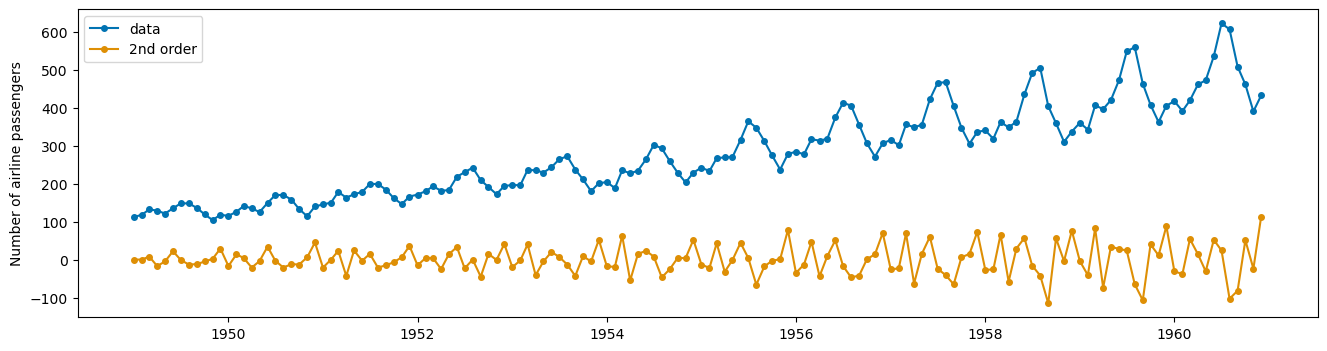

In [62]:
transformer_2 = Differencer(lags= [1, 1])
data_transformed_2 = transformer_2.fit_transform(data)
plot_series(data, data_transformed_2, labels = ['data','2nd order'])

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

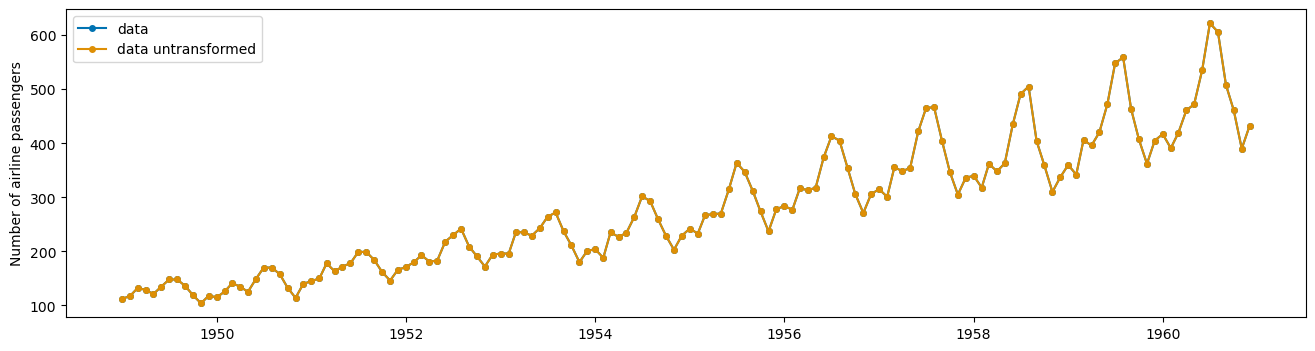

In [63]:
data_untransformed = transformer_1.inverse_transform(data_transformed_1) #untransforming data
plot_series(data, data_untransformed, labels = ['data', 'data untransformed'])

### Lets see if the models do better on data that is transformed. The predictions will then have the inverse transformation applied to them to get the data into values applicable to the original data.

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

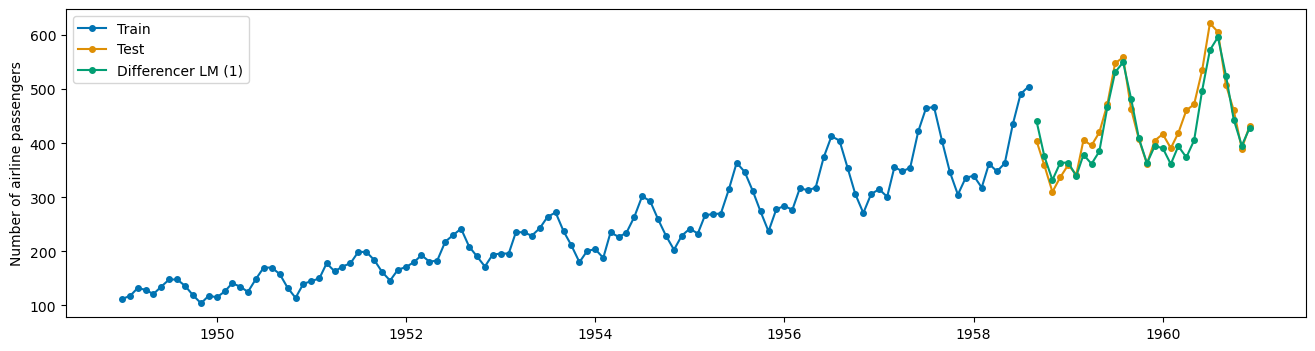

In [64]:
from sktime.transformations.series.difference import Differencer
transformer_1 = Differencer(lags=1)
train_transformed_1 = transformer_1.fit_transform(y_train)

lm_model = LinearRegression()
lm_fc = make_reduction(
    lm_model,
    window_length = 12,
    strategy = 'recursive'
)

lm_fc.fit(train_transformed_1)
xformed_preds = lm_fc.predict(fh)
pred_inverse_1 = transformer_1.inverse_transform(xformed_preds)

plot_series(y_train, y_test, pred_inverse_1, labels = ['Train', 'Test', 'Differencer LM (1)'])

In [65]:
mape = MeanAbsolutePercentageError(symmetric=False)
smape = MeanAbsolutePercentageError(symmetric=True)
lm_diff1_mape_value = mape(y_test, pred_inverse_1)
lm_diff1_smape_value = smape(y_test, pred_inverse_1)
print(f'MAPE value: {lm_diff1_mape_value} | SMAPE value: {lm_diff1_smape_value}')

MAPE value: 0.05226547662031062 | SMAPE value: 0.05379057473658088


(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

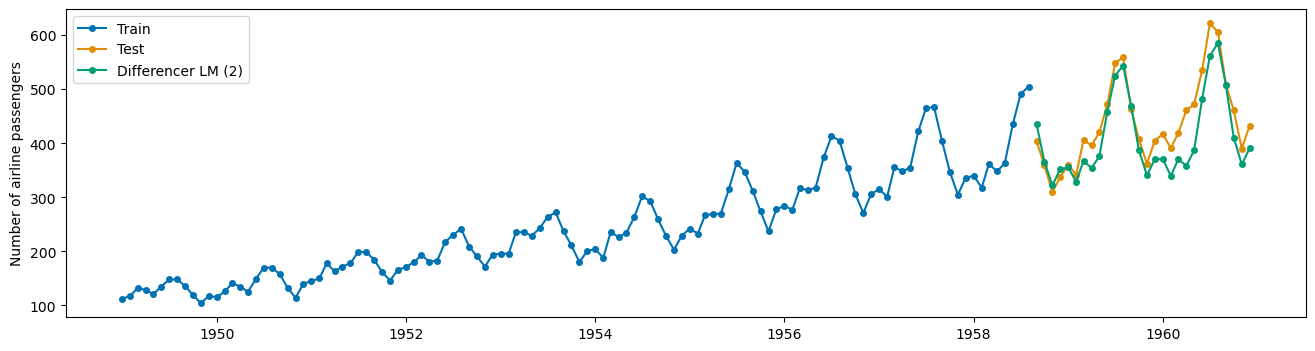

In [66]:
from sktime.transformations.series.difference import Differencer
transformer_2 = Differencer(lags=[1, 1])
train_transformed_2 = transformer_2.fit_transform(y_train)

lm_model = LinearRegression()
lm_fc = make_reduction(
    lm_model,
    window_length = 12,
    strategy = 'recursive'
)

lm_fc.fit(train_transformed_2)
xformed_preds = lm_fc.predict(fh)
pred_inverse_2 = transformer_2.inverse_transform(xformed_preds)

plot_series(y_train, y_test, pred_inverse_2, labels = ['Train', 'Test', 'Differencer LM (2)'])

In [67]:
mape = MeanAbsolutePercentageError(symmetric=False)
smape = MeanAbsolutePercentageError(symmetric=True)
lm_diff2_mape_value = mape(y_test, pred_inverse_2)
lm_diff2_smape_value = smape(y_test, pred_inverse_2)
print(f'MAPE value: {lm_diff2_mape_value} | SMAPE value: {lm_diff2_smape_value}')

MAPE value: 0.07557566542072412 | SMAPE value: 0.07965618891795602


In [68]:
xgb_model = xgb.XGBRegressor(objective = 'reg:squarederror')
xgb_fc = make_reduction(
    xgb_model,
    window_length = 12,
    strategy = 'recursive'
)
cv = SlidingWindowSplitter(initial_window=20, window_length=12)
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1]
}
xgb_fc_gscv = ForecastingGridSearchCV(xgb_fc, strategy="refit", cv=cv, param_grid=param_grid)
xgb_fc_gscv.fit(train_transformed_1)
print(xgb_fc_gscv.best_params_)

{'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}


In [69]:
best_xgb_model = xgb.XGBRegressor('reg:squarederror')
best_xgb_model.set_params(**xgb_fc_gscv.best_params_)
best_xgb_fc = make_reduction(
    best_xgb_model,
    window_length = 12,
    strategy = 'recursive'
)

C:\Users\akozi\anaconda3\Lib\site-packages\xgboost\core.py:748: FutureWarning: Pass `objective` as keyword args.
  warnings.warn(msg, FutureWarning)


(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

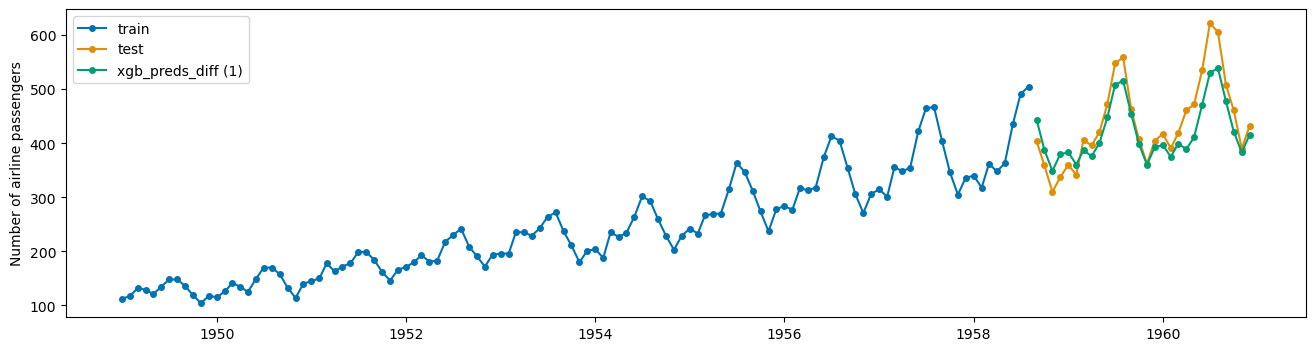

In [70]:
best_xgb_fc.fit(train_transformed_1)
best_xgb_preds = best_xgb_fc.predict(fh)
xgb_inversed_preds = transformer_1.inverse_transform(best_xgb_preds)
plot_series(y_train, y_test, xgb_inversed_preds , labels = ['train', 'test', 'xgb_preds_diff (1)'])

In [71]:
mape = MeanAbsolutePercentageError(symmetric=False)
smape = MeanAbsolutePercentageError(symmetric=True)
xgb_diff1_mape_value = mape(y_test, xgb_inversed_preds)
xgb_diff1_smape_value = smape(y_test, xgb_inversed_preds)
print(f'MAPE value: {xgb_diff1_mape_value} | SMAPE value: {xgb_diff1_smape_value}')

MAPE value: 0.0703104904539008 | SMAPE value: 0.07184890053066433


In [72]:
import pandas as pd
pd.DataFrame({
    'MAPE':[lm_mape_value, rf_mape_value, xgb_mape_value, lm_diff1_mape_value, lm_diff2_mape_value, xgb_diff1_mape_value],
    'SMAPE':[lm_smape_value, rf_smape_value, xgb_smape_value, lm_diff1_smape_value, lm_diff2_smape_value, xgb_diff1_smape_value]},
             index = ['Linear Model', 'Random Forest Model', 'XGBoost Model', 'Linear Model (1) Diff', 'Linear Model (2) Diff', 'XGB Model (1) Diff']
            )

,MAPE,SMAPE
Linear Model,0.080465,0.077947
Random Forest Model,0.086387,0.087036
XGBoost Model,0.118936,0.129519
Linear Model (1) Diff,0.052265,0.053791
Linear Model (2) Diff,0.075576,0.079656
XGB Model (1) Diff,0.070310,0.071849


From the above dataframe, we can see a few things. First, on this data, the linear regression model tends to be more accurate. Second, applying the differencer transformation before model fitting and predition then applying the inverse transformation improves model accuracy. All of these models have been focused on the use of the make_reduction forecaster; we will try Auto ARIMA. ARMA requires stationary data, which is hardly ever an assumption we can rely on in real world data (our data is not stationary) so we wil focus on ARIMA instead.

### Using Auto ARIMA

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

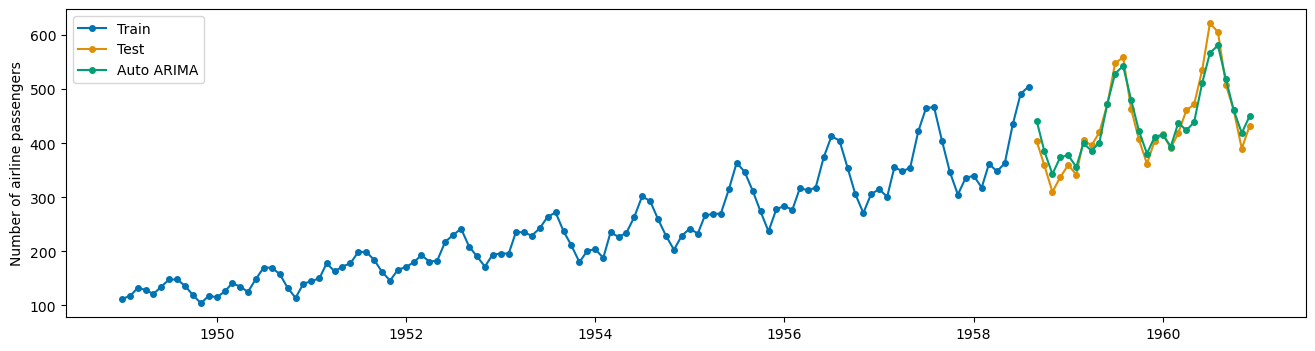

In [73]:
!pip install --quiet pmdarima
from sktime.forecasting.arima import AutoARIMA
AA_forecaster = AutoARIMA(sp=12, suppress_warnings=True)
AA_forecaster.fit(y_train)
AA_preds = AA_forecaster.predict(fh)
plot_series(y_train, y_test, AA_preds, labels = ['Train', 'Test', 'Auto ARIMA'])

In [74]:
mape = MeanAbsolutePercentageError(symmetric=False)
smape = MeanAbsolutePercentageError(symmetric=True)
AA_mape_value = mape(y_test, AA_preds)
AA_smape_value = smape(y_test, AA_preds)
print(f'MAPE value: {AA_mape_value} | SMAPE value: {AA_smape_value}')

MAPE value: 0.04592802391848562 | SMAPE value: 0.04545810782145633


Here we can see that the Auto ARIMA gave us the lowest error yet.